In [5]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA-


In [7]:
df.shape

(1338, 7)

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

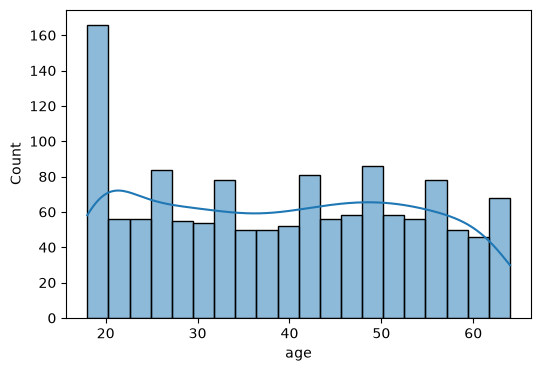

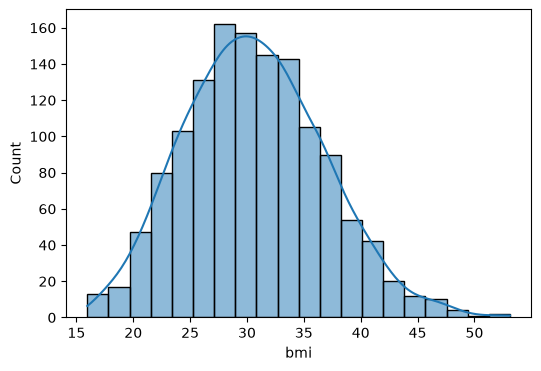

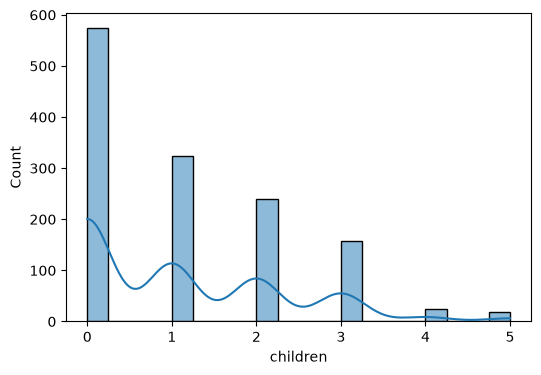

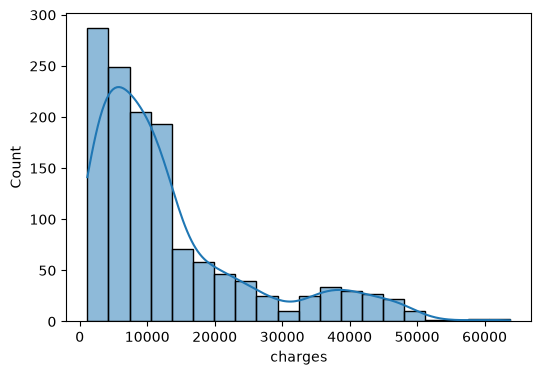

In [13]:
numeric_columbs=['age', 'bmi', 'children', 'charges']
for col in numeric_columbs:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

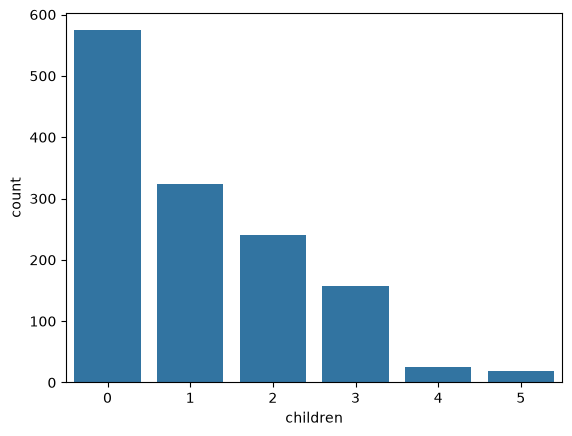

In [14]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

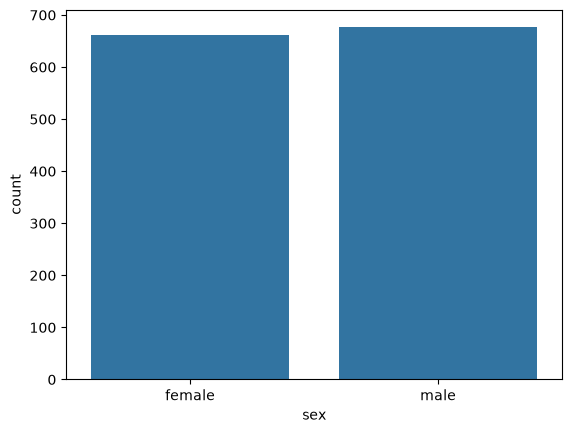

In [15]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

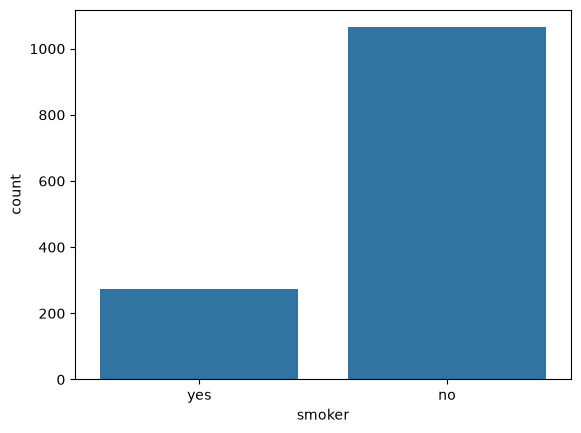

In [16]:
sns.countplot(x=df['smoker'])

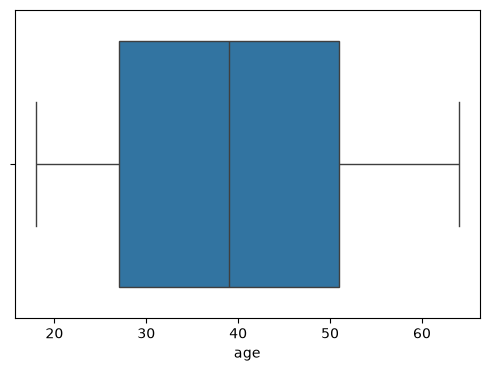

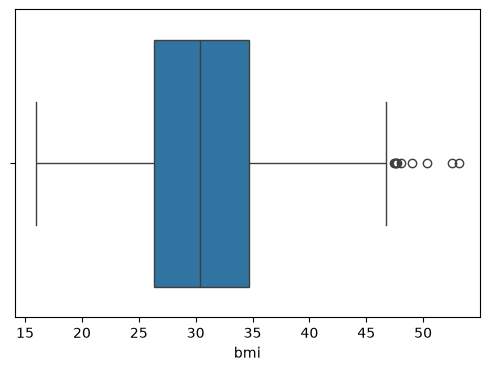

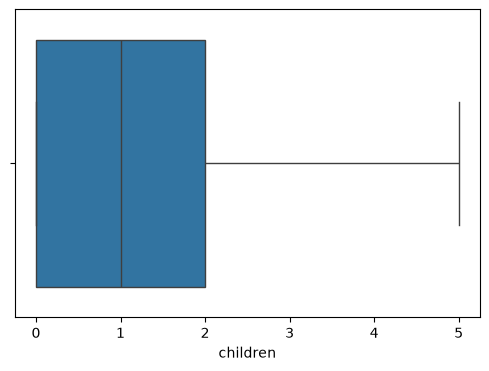

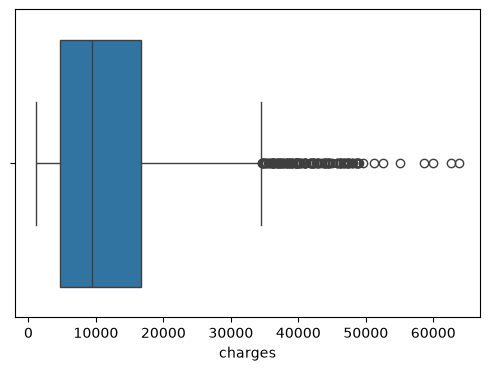

In [17]:
for i in numeric_columbs:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i])

<Axes: >

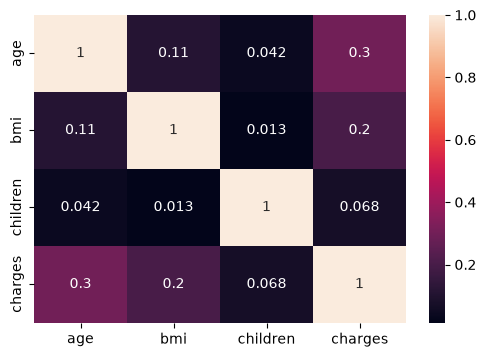

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)             # to check correlation with other factors!

# data cleaning & preproccesing

In [19]:
df_cleaned=df.copy()

In [20]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
df_cleaned.shape

(1338, 7)

In [22]:
df_cleaned.drop_duplicates(inplace=True)           # inplace = true ->  means directly change in df_cleaned dont return a simply copy

In [23]:
df_cleaned.duplicated().sum()                      # now no duplicated value exist!!

np.int64(0)

In [24]:
df_cleaned.shape

(1337, 7)

In [25]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
df_cleaned.dtypes                   # we have make our data is numerical value as so make sex , smoker & region into integer

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [27]:
df_cleaned.value_counts('sex')

## if data is inconsitent

# df_cleaned["Gender"] = df_cleaned["Gender"].replace({
#     "M": "Male",
#     "male": "Male",
#     "F": "Female",
#     "female": "Female"
# })


sex
male      675
female    662
Name: count, dtype: int64

In [28]:
#level encoding!!

df_cleaned['sex']=df_cleaned['sex'].map({'male':1 , 'female': 0})

In [29]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [30]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [31]:
df_cleaned.value_counts('smoker')   

smoker
no     1063
yes     274
Name: count, dtype: int64

In [32]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1 , 'no': 0})

In [33]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [34]:
df_cleaned.rename(columns={
    'sex':'is_male',
    'smoker':'is_smoker'
},inplace=True)

In [35]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [36]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [37]:
# for this data we use 1 hot encoding!!                

df_cleaned=pd.get_dummies(df_cleaned, columns = ['region'])

In [38]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [39]:
df_cleaned=df_cleaned.astype(int)
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27,0,1,16884,0,0,0,1
1,18,1,33,1,0,1725,0,0,1,0
2,28,1,33,3,0,4449,0,0,1,0
3,33,1,22,0,0,21984,0,1,0,0
4,32,1,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30,3,0,10600,0,1,0,0
1334,18,0,31,0,0,2205,1,0,0,0
1335,18,0,36,0,0,1629,0,0,1,0
1336,21,0,25,0,0,2007,0,0,0,1


# feature engineering !!



<Axes: xlabel='bmi', ylabel='Count'>

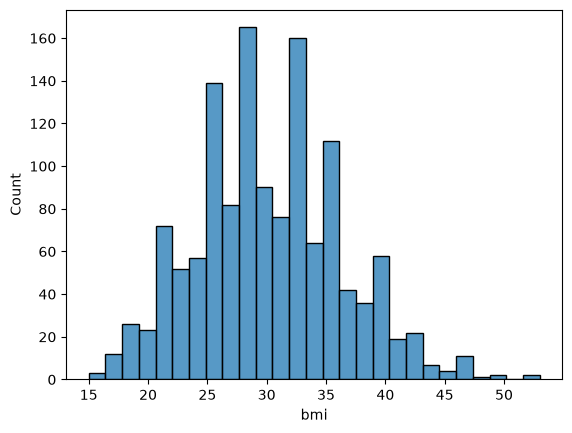

In [40]:
sns.histplot(df_cleaned['bmi'])

In [41]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],                 #inf -> infinity
    labels=['underweight','normal','overweight','obesity']
)

In [42]:
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,0,27,0,1,16884,0,0,0,1,overweight
1,18,1,33,1,0,1725,0,0,1,0,obesity
2,28,1,33,3,0,4449,0,0,1,0,obesity
3,33,1,22,0,0,21984,0,1,0,0,normal
4,32,1,28,0,0,3866,0,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30,3,0,10600,0,1,0,0,obesity
1334,18,0,31,0,0,2205,1,0,0,0,obesity
1335,18,0,36,0,0,1629,0,0,1,0,obesity
1336,21,0,25,0,0,2007,0,0,0,1,overweight


In [43]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'])

In [44]:
df_cleaned=df_cleaned.astype(int)

In [45]:
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,19,0,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,1,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,1,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,1,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,1,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,0,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,0,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,0,25,0,0,2007,0,0,0,1,0,0,1,0


In [46]:
df_cleaned.columns

Index(['age', 'is_male', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_underweight', 'bmi_category_normal',
       'bmi_category_overweight', 'bmi_category_obesity'],
      dtype='str')

In [47]:
#feature scaling!!            to make [bmi & age & children] in 01 format

from sklearn.preprocessing import StandardScaler                   #standardization [-3 to 3]

cols=['age','bmi','children']
scaler=StandardScaler()

df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [48]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,1,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,1,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,1,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,1,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0


# feature extraction!!

In [49]:
from scipy.stats import pearsonr

selected_features=[
    'age', 'bmi', 'children', 'is_male' ,'is_smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_underweight', 'bmi_category_normal',
       'bmi_category_overweight', 'bmi_category_obesity'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
12,bmi_category_obesity,0.200348
1,bmi,0.196236
7,region_southeast,0.073577
2,children,0.067390
3,is_male,0.058046
5,region_northeast,0.005946
6,region_northwest,-0.038695
8,region_southwest,-0.043637


In [55]:
cat_features=[
    'is_male', 'is_smoker',
    'region_northeast','region_northwest','region_southeast','region_southwest',
    'bmi_category_underweight','bmi_category_normal','bmi_category_overweight','bmi_category_obesity'
]

In [56]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_male,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_obesity,8.515711,0.036473,Reject Null (Keep Feature)
region_northeast,6.438442,0.092122,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_normal,3.708088,0.29476,Accept Null (Drop Feature)
bmi_category_underweight,3.37403,0.337471,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [57]:
final_df=df_cleaned[['age','is_male','bmi','children','is_smoker','region_southeast','bmi_category_obesity','charges']]

In [58]:
final_df                                                       # final dataset to train model

,age,is_male,bmi,children,is_smoker,region_southeast,bmi_category_obesity,charges
0,-1.440418,0,-0.517949,-0.909234,1,0,0,16884
1,-1.511647,1,0.462463,-0.079442,0,1,1,1725
2,-0.799350,1,0.462463,1.580143,0,1,1,4449
3,-0.443201,1,-1.334960,-0.909234,0,0,0,21984
4,-0.514431,1,-0.354547,-0.909234,0,0,0,3866
...,...,...,...,...,...,...,...,...
1333,0.767704,1,-0.027743,1.580143,0,0,1,10600
1334,-1.511647,0,0.135659,-0.909234,0,0,1,2205
1335,-1.511647,0,0.952670,-0.909234,0,1,1,1629
1336,-1.297958,0,-0.844753,-0.909234,0,0,0,2007


In [59]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [60]:
from sklearn.model_selection import train_test_split

In [62]:
X=final_df.drop('charges',axis=1)
y=final_df['charges']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [67]:
from sklearn.linear_model import LinearRegression

In [69]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 3489.11, -72.39, 565.67,...,23080.28, -264.14, 3285.92]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['age','is_male','bmi',...,'is_smoker','region_southeast', 'bmi_category_obesity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6841
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [70]:
y_predict=model.predict(X_test)

In [72]:
y_predict

array([ 7856.41808069,  5379.07145062, 14613.47489419, 32465.93193508,
        8955.35729283, 13336.43605749, 30199.07309038,  1403.40503994,
       11196.90873514, 10018.65838301, 10818.71629044, 32144.43533014,
       31550.26059902, 16230.55597963, 10285.99989714,  8488.6608457 ,
        5487.64476113, 32465.09672212,  3304.46601962,  3877.00422671,
        4760.01023433, 28796.29743032, 13870.98195763, 29541.88243902,
       31520.15678042,  6344.44675222, 35026.69683204, 37880.73853364,
       12490.06211178, 14238.95332785,  7573.09915473, 13049.08020135,
         516.21534048, 11339.74207305, 37584.28749479, 13356.84393437,
        3706.96614326,  4537.12786929, 31481.80485676,  8009.55465514,
        6075.79442888, 30404.81913857, 35276.56346051, 13099.59189682,
        7977.69705664,  2987.00634487,  5174.11237148,  7620.54073087,
        3522.89053725, 10388.99625751,  7820.00530896, 10505.68054495,
       30331.09138384,  4687.62077185, 11676.0149257 , 11446.77536361,
      

In [76]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,y_predict)
r2

0.8040712413347118

In [78]:
n=X_test.shape[0]
p=X_test.shape[1]

adjusted_r2= 1 - ((1 - r2) * (n - 1) / (n - p - 1))
adjusted_r2

0.7987962362937232